In [1]:
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})

In [2]:
res=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/new_regime.csv')   

In [3]:
res['new_regime'] = res['new_regime'].replace(5, 4)

In [4]:
lonlim = (-82, -32)
latlim = (-60, 15)

In [5]:
# Create pivot table from DataFrame: convert from long to wide format with lat/lon as coordinates
df_regime = res.pivot_table(index='lat', columns='lon', values='new_regime')
# Convert pivot table to xarray DataArray with proper dimensions and coordinate labels
da_regime = xr.DataArray(df_regime, dims=('lat', 'lon'), 
                        coords={'lat': df_regime.index, 'lon': df_regime.columns})

In [6]:
# Load Amazon shapefile and read into GeoDataFrame
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
amazon_vector = gpd.read_file(amazon_shapefile)

# Dissolve all polygons into a single multi-polygon feature
# (Alternative commented line shows filtering for specific region before dissolving)
amazon_vector = amazon_vector.dissolve()
# amazon_vector = amazon_vector[amazon_vector['name'] == 'Amazonia - sensu stricto'].dissolve()

# Select the first (and only) feature from the dissolved GeoDataFrame
amazon_border = amazon_vector.loc[[0]]

# Load global geography regions shapefile for additional geographic context
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
geography_vector = gpd.read_file(geography_shapefile)

/tmp/ipykernel_2174498/3156019129.py:34: UltraPlotWarning: Ignoring unused keyword arg(s): {'vmin': 1.0, 'vmax': 5.0}
  im = ax.pcolormesh(


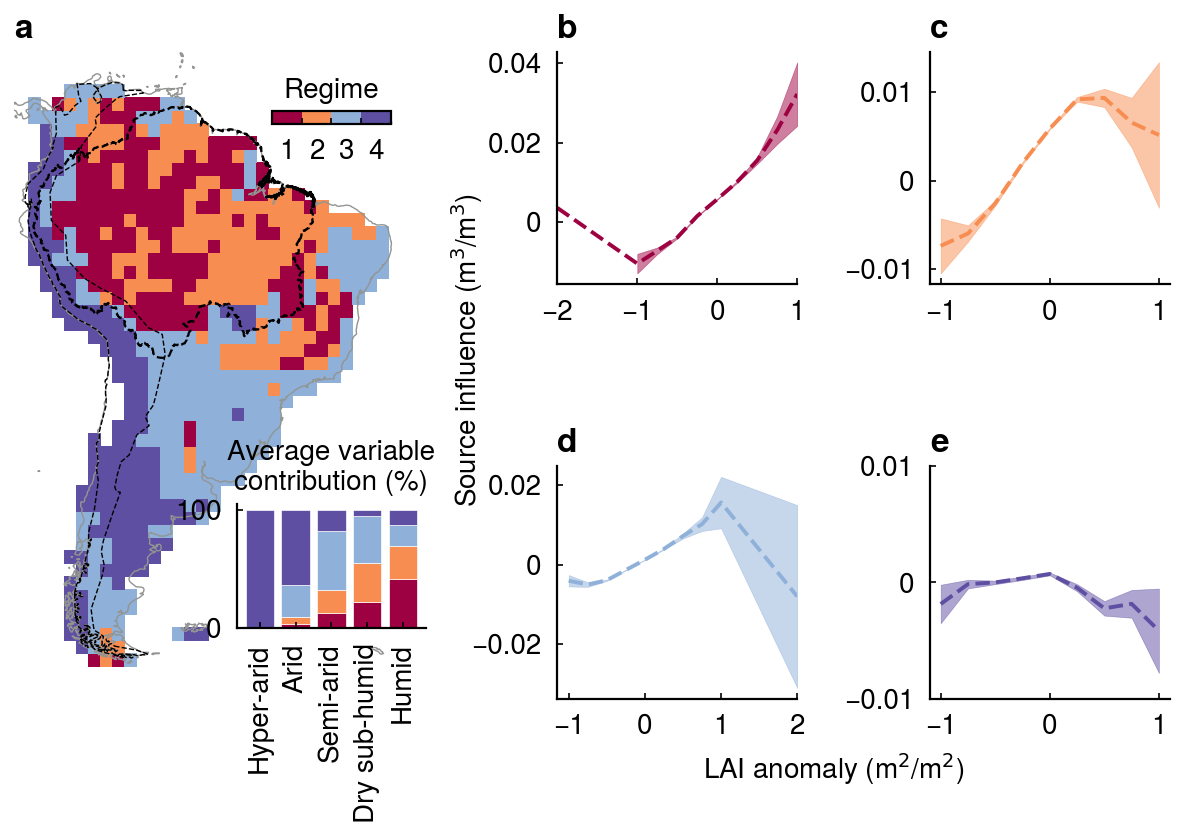

In [29]:
# Define subplot arrangement (2x3 grid)
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2, 3],
    [1, 4, 5],
]

# Create figure with specified parameters
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
# Create subplots with cylindrical projection for first subplot, others default
axs = fig.subplots(arrray, proj={1: 'cyl'}, abc=True, width_ratios=[2.5, 1.5, 1.5], height_ratios=[1, 1])

# First subplot: Regime classification map
ax = axs[0]
# Format axes with longitude and latitude limits
ax.format(lonlim=lonlim, latlim=latlim, linewidth=0)

# Define color mapping for different regime values
value_color_map = {
    1: '#9E0142',
    2: '#F88D51',
    3: '#8FB0D9',
    4: '#5E4FA2'
}
# Create color list and colormap
colors = [value_color_map[v] for v in range(1, 5)]
cmap = ListedColormap(colors)

# Define boundaries for color normalization
bounds = [1, 2, 3, 4, 5]

# Create boundary normalization for discrete color mapping
norm = BoundaryNorm(bounds, cmap.N)
# Plot regime classification as colormesh
im = ax.pcolormesh(
    da_regime.lon,
    da_regime.lat,
    da_regime.values,
    norm=norm,
    cmap=cmap,
    shading='flat',
    transform=ccrs.PlateCarree()
)

#############################
# Create colorbar for regime classification
cax = fig.add_axes([0.23, 0.85, 0.1, 0.015])  # Adjust position and size
cbar = plt.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    ticks=[1, 2, 3, 4], 
    extend='neither',       
    spacing='uniform', ticklocation='bottom')  
# Set colorbar tick labels and formatting
cbar.set_ticklabels(['    1', '    2', '    3', '    4'], fontsize=10)
cbar.ax.xaxis.set_label_position('top')  # Set label position to top
cbar.set_label('Regime', loc='center', labelpad=5)  

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

#################################
# Define bin centers for x-axis
bin_centers = [-2, -1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1, 2]

# Plot regime-specific relationships in subplots 2-5
for i in range(4):
    ax = axs[i + 1]
    # Load regime-specific data from CSV files
    df_regime_i = pd.read_csv('regime_' + str(i + 1) + '.csv')
    
    alpha = 0.5
    # Plot mean values as dashed line
    ax.plot(bin_centers, df_regime_i['y_mean'], color=colors[i], linestyle='--')
    # Fill confidence interval area
    ax.fill_between(bin_centers, df_regime_i['ci_lower'], df_regime_i['ci_upper'], 
                   color=colors[i], alpha=alpha)
    
    # Remove top and right spines for cleaner appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set y-axis labels for specific subplots
ylabel = axs[3].set_ylabel('Source influence (m${^3}$/m${^3}$)', labelpad=-5)
ylabel.set_position((0, 1.5))

# ylabel.set_position((0, 1.5))

# Remove y-axis labels from some subplots
axs[2].set_ylabel('')
axs[1].set_ylabel('')
axs[4].set_ylabel('')
# Set x-axis labels
xlabel=axs[4].set_xlabel('LAI anomaly (m${^2}$/m${^2}$)')
xlabel.set_position((-0.4, -1))
# lim
axs[1].set_xlim(-2,1)
axs[1].set_xticks([-2,-1,0,1])
axs[3].set_xticks([-1,0,1,2])
axs[4].set_yticks([-0.01,0,0.01])
#################################
# Create inset axes for variable contribution bar chart
ax_inset = fig.add_axes([0.2, 0.24, 0.16, 0.15], title='Average variable\ncontribution (%)', titlesize=10)

# Calculate stacked percentage data by regime and aridity index bin
stack_data = res.groupby(['ai_bin', 'new_regime']).size().unstack()
stack_data = stack_data.div(stack_data.sum(axis=1), axis=0) * 100  # Convert to percentage

# Reindex to specific aridity index order
new_index_order = ['Hyper-arid', 'Arid', 'Semi-arid', 'Dry sub-humid', 'Humid']
stack_data = stack_data.reindex(index=new_index_order)

# Define colors for stacked bars
colors0 = ['#9E0142', '#F88D51', '#8FB0D9', '#5E4FA2']

# Plot stacked bar chart
stack_data.plot(
    kind='bar', 
    stacked=True, 
    color=colors0,
    edgecolor='white',
    width=0.8,
    ax=ax_inset
)

# Format inset plot
ax_inset.set_xlabel('')
ax_inset.legend().remove()  # Remove legend
ax_inset.spines['top'].set_visible(False)
ax_inset.spines['right'].set_visible(False)